# 01b — MCI Time-to-Dementia **Survival** Cohort Audit

**Pivot from the binary audit (`01_mci_24m_cohort_audit.ipynb`).** The prior notebook
required a follow-up visit inside a strict **18–30 month** window to call someone
"stable MCI", which discarded most participants (only **139 / 535** were outcome-ascertained).

This notebook re-frames the outcome as **time-to-dementia with right-censoring**, so a
participant with *any* usable post-anchor clinical follow-up contributes information —
either as an observed dementia **event** or as **censored** at their last valid non-dementia
visit. Short *and* long follow-up both count.

**Scientific question (future study):** *Among people with MCI at the time of a blood
draw, can a small plasma biomarker panel help stratify risk of progression to dementia
over time, including estimated risk by 24 months?* This is a clinician-facing **research
risk-stratification** concept — **not** a diagnostic tool, not a CN/MCI/Dementia classifier,
not a claim of clinical readiness.

**This notebook does NOT fit any model** (no Cox, no random survival forest, no boosted
survival, no ML). It builds and validates a *survival-ready* cohort, quantifies usable
follow-up and events, and judges feasibility of a future small survival pilot.

Data sources and diagnosis harmonization are inherited from the prior audit
(verified again below).

## 0. Setup, paths, configuration

In [1]:
from __future__ import annotations
import textwrap
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 170)
matplotlib.rcParams["figure.dpi"] = 110


def find_project_root(start: Path) -> Path:
    for cand in [start.resolve(), *start.resolve().parents]:
        if (cand / "Data" / "raw").is_dir():
            return cand
    raise FileNotFoundError("Could not locate Data/raw above %s" % start)


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "Data" / "raw"
OUT_DIR = PROJECT_ROOT / "outputs" / "01b_mci_survival_cohort_audit"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- configuration (explicit & documented) --------------------------------
MISSING_SENTINELS = [-4, -5]              # ADNI missing codes in these tables
NONPOSITIVE_IS_MISSING = True             # plasma concentrations must be > 0
ALIGN_TOL_DAYS = 90                       # ±90d diagnosis<->blood alignment (kept from prior audit)
DAYS_PER_YEAR = 365.25
DAYS_PER_MONTH = 30.4375
HORIZONS_DAYS = {"365": 365, "730": 730, "1095": 1095}   # 12 / 24 / 36 months
CORE_ASSAYS = ["ptau217", "abeta42", "abeta40", "nfl", "gfap"]  # "at least one usable" for anchor

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR     :", OUT_DIR)
print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)


def save_table(df: pd.DataFrame, name: str, index: bool = False) -> Path:
    path = OUT_DIR / name
    df.to_csv(path, index=index)
    print(f"  saved -> {path.relative_to(PROJECT_ROOT)}  ({df.shape[0]}x{df.shape[1]})")
    return path


PROJECT_ROOT: /Users/zoeyd/Desktop/Predict_AD_from_Biomarkers
OUT_DIR     : /Users/zoeyd/Desktop/Predict_AD_from_Biomarkers/outputs/01b_mci_survival_cohort_audit
pandas 3.0.1 | numpy 2.4.3 | matplotlib 3.10.8


## 1. Data-discovery and logic summary

Same raw ADNI CRFs as the prior audit, joined on **`RID`**. Visits carry `VISCODE2` and
dates (`EXAMDATE` / `VISDATE`). Diagnosis coding was verified in `01` against the
`DXNORM/DXMCI/DXAD` detail flags: **`1=CN, 2=MCI, 3=Dementia`**.

In [2]:
def clean_sentinels(s: pd.Series) -> pd.Series:
    v = pd.to_numeric(s, errors="coerce")
    return v.mask(v.isin(MISSING_SENTINELS))


# ---- load raw ----
dxsum = pd.read_csv(RAW_DIR / "All_Subjects_DXSUM_05Mar2026.csv",
                    usecols=["PTID", "RID", "VISCODE2", "EXAMDATE", "DIAGNOSIS"])
plasma = pd.read_csv(RAW_DIR / "All_Subjects_UPENN_PLASMA_FUJIREBIO_QUANTERIX_05Mar2026.csv",
                     usecols=["PTID", "RID", "VISCODE2", "EXAMDATE",
                              "pT217_F", "AB42_F", "AB40_F", "AB42_AB40_F", "NfL_Q", "GFAP_Q"])
apoe = pd.read_csv(RAW_DIR / "All_Subjects_APOERES_05Mar2026.csv", usecols=["RID", "GENOTYPE"])
age = pd.read_csv(RAW_DIR / "All_Subjects_My_Table_05Mar2026.csv")  # subject_id(==PTID), entry_age
cdr = pd.read_csv(RAW_DIR / "All_Subjects_CDR_05Mar2026.csv", usecols=["RID", "VISDATE", "CDVERSION", "CDRSB"])
mmse = pd.read_csv(RAW_DIR / "All_Subjects_MMSE_05Mar2026.csv", usecols=["RID", "VISDATE", "MMSCORE"])
moca = pd.read_csv(RAW_DIR / "All_Subjects_MOCA_05Mar2026.csv", usecols=["RID", "VISDATE", "MOCA"])
faq = pd.read_csv(RAW_DIR / "All_Subjects_FAQ_05Mar2026.csv", usecols=["RID", "VISDATE", "FAQTOTAL"])

# Confirm no dedicated death / withdrawal table exists among raw files.
_death_like = [p.name for p in RAW_DIR.glob("*.csv")
               if any(k in p.name.upper() for k in ["DEATH", "REGISTRY", "TREATDIS", "WITHDRAW"])]
print("Death/withdrawal/registry tables found:", _death_like or "NONE (censor at last clinical dx)")
print("Loaded:", {k: len(v) for k, v in
                  dict(dxsum=dxsum, plasma=plasma, apoe=apoe, age=age,
                       cdr=cdr, mmse=mmse, moca=moca, faq=faq).items()})


Death/withdrawal/registry tables found: NONE (censor at last clinical dx)
Loaded: {'dxsum': 16088, 'plasma': 2178, 'apoe': 3253, 'age': 5031, 'cdr': 14734, 'mmse': 14709, 'moca': 9072, 'faq': 13385}


In [3]:
discovery = pd.DataFrame([
    dict(item="Diagnosis / longitudinal status", value="All_Subjects_DXSUM_05Mar2026.csv | DIAGNOSIS, VISCODE2, EXAMDATE"),
    dict(item="Primary plasma panel", value="All_Subjects_UPENN_PLASMA_FUJIREBIO_QUANTERIX_05Mar2026.csv"),
    dict(item="APOE", value="All_Subjects_APOERES_05Mar2026.csv | GENOTYPE -> APOE4_COUNT"),
    dict(item="Age / demographic", value="All_Subjects_My_Table_05Mar2026.csv | entry_age (no datestamp)"),
    dict(item="Clinical benchmarks", value="CDR(CDRSB), MMSE(MMSCORE), MOCA(MOCA), FAQ(FAQTOTAL)"),
    dict(item="Participant ID field", value="RID (join key); PTID (human-readable)"),
    dict(item="Blood-draw date field", value="plasma.EXAMDATE"),
    dict(item="Diagnosis-date field", value="DXSUM.EXAMDATE"),
    dict(item="Diagnosis mapping", value="1=CN, 2=MCI, 3=Dementia; blank -> unknown/other (excluded)"),
    dict(item="Plasma assay columns used", value="pT217_F, AB42_F, AB40_F, AB42_AB40_F, NfL_Q, GFAP_Q"),
    dict(item="Sentinel values handled", value="-4, -5 -> NaN; non-positive concentration -> NaN (flagged)"),
    dict(item="Anchor definition", value="earliest MCI-aligned plasma draw (±90d) with >=1 usable core assay"),
    dict(item="Anchor tie-break", value="earliest DATE; then first row order (deterministic)"),
    dict(item="Survival time origin", value="plasma anchor date"),
    dict(item="Survival event rule", value="first post-anchor Dementia diagnosis (event_indicator=1)"),
    dict(item="Censoring rule", value="last valid post-anchor non-dementia (CN/MCI) diagnosis date"),
    dict(item="No usable follow-up", value="no valid post-anchor dx and no dementia event -> excluded from survival"),
])
save_table(discovery, "data_discovery_survival_summary.csv")
discovery


  saved -> outputs/01b_mci_survival_cohort_audit/data_discovery_survival_summary.csv  (17x2)


,item,value
0,Diagnosis / longitudinal status,"All_Subjects_DXSUM_05Mar2026.csv | DIAGNOSIS, ..."
1,Primary plasma panel,All_Subjects_UPENN_PLASMA_FUJIREBIO_QUANTERIX_...
2,APOE,All_Subjects_APOERES_05Mar2026.csv | GENOTYPE ...
3,Age / demographic,All_Subjects_My_Table_05Mar2026.csv | entry_ag...
4,Clinical benchmarks,"CDR(CDRSB), MMSE(MMSCORE), MOCA(MOCA), FAQ(FAQ..."
5,Participant ID field,RID (join key); PTID (human-readable)
6,Blood-draw date field,plasma.EXAMDATE
7,Diagnosis-date field,DXSUM.EXAMDATE
8,Diagnosis mapping,"1=CN, 2=MCI, 3=Dementia; blank -> unknown/othe..."
9,Plasma assay columns used,"pT217_F, AB42_F, AB40_F, AB42_AB40_F, NfL_Q, G..."


## 2. Diagnosis harmonization (unchanged from prior audit, re-verified)

In [4]:
def harmonize_diagnosis(code: float) -> str:
    return {1.0: "CN", 2.0: "MCI", 3.0: "Dementia"}.get(code, "unknown/other")


dx = dxsum.copy()
dx["DATE"] = pd.to_datetime(dx["EXAMDATE"], errors="coerce")
dx["dx_code"] = pd.to_numeric(dx["DIAGNOSIS"], errors="coerce")
dx["dx_harmonized"] = dx["dx_code"].map(harmonize_diagnosis)

_rawc = dx["dx_code"].value_counts(dropna=False)
dx_map = pd.DataFrame([
    dict(raw_value=1, harmonized="CN", n_rows=int(_rawc.get(1.0, 0)),
         is_event="No", is_censoring_eligible="Yes",
         notes="Cognitively normal. Valid non-dementia -> can serve as censoring visit."),
    dict(raw_value=2, harmonized="MCI", n_rows=int(_rawc.get(2.0, 0)),
         is_event="No", is_censoring_eligible="Yes",
         notes="MCI. Anchor-defining; valid non-dementia -> censoring visit."),
    dict(raw_value=3, harmonized="Dementia", n_rows=int(_rawc.get(3.0, 0)),
         is_event="Yes", is_censoring_eligible="No",
         notes="Dementia/AD (DXAD==1). First post-anchor occurrence = survival event."),
    dict(raw_value="(blank)", harmonized="unknown/other", n_rows=int(_rawc.get(np.nan, 0)),
         is_event="No", is_censoring_eligible="No",
         notes="Ambiguous. Never used to define event or censor."),
])
save_table(dx_map, "diagnosis_harmonization_survival.csv")

# clean dated diagnosis history (deterministic tie-break = highest severity on same day)
n_no_date = dx["DATE"].isna().sum(); n_no_dx = dx["dx_code"].isna().sum()
dxh = dx.dropna(subset=["DATE", "dx_code"]).sort_values(["RID", "DATE", "dx_code"])
n_conflict_sameday = dxh.duplicated(["RID", "DATE"], keep=False).sum()
dxh = dxh.drop_duplicates(["RID", "DATE"], keep="last")
print(f"Dropped {n_no_date} rows w/o date, {n_no_dx} w/o diagnosis. "
      f"Same-day records collapsed (tie-break=highest severity): {n_conflict_sameday} rows.")
print(f"Clean dx history: {len(dxh)} visits, {dxh['RID'].nunique()} participants.")
dx_map


  saved -> outputs/01b_mci_survival_cohort_audit/diagnosis_harmonization_survival.csv  (4x6)
Dropped 115 rows w/o date, 45 w/o diagnosis. Same-day records collapsed (tie-break=highest severity): 76 rows.
Clean dx history: 15935 visits, 3763 participants.


,raw_value,harmonized,n_rows,is_event,is_censoring_eligible,notes
0,1,CN,6404,No,Yes,Cognitively normal. Valid non-dementia -> can ...
1,2,MCI,6623,No,Yes,MCI. Anchor-defining; valid non-dementia -> ce...
2,3,Dementia,3016,Yes,No,Dementia/AD (DXAD==1). First post-anchor occur...
3,(blank),unknown/other,45,No,No,Ambiguous. Never used to define event or censor.


## 3. Clean plasma panel (usable-assay definition)

Sentinels (−4, −5) → `NaN`; non-positive concentrations → `NaN` and counted as
suspicious (never deleted from the raw master). An assay is **usable** at a draw if it is
present, non-sentinel, and > 0. The broad anchor needs **≥ 1** usable assay among
p-tau217 / Aβ42 / Aβ40 / NfL / GFAP.

In [5]:
plasma_c = plasma.copy()
plasma_c["DATE"] = pd.to_datetime(plasma_c["EXAMDATE"], errors="coerce")
SRC = {"ptau217": "pT217_F", "abeta42": "AB42_F", "abeta40": "AB40_F",
       "nfl": "NfL_Q", "gfap": "GFAP_Q", "ratio_ab42_ab40_vendor": "AB42_AB40_F"}
suspicious = {}
for name, col in SRC.items():
    v = clean_sentinels(plasma_c[col])
    if NONPOSITIVE_IS_MISSING:
        bad = v.notna() & (v <= 0)
        suspicious[name] = int(bad.sum())
        v = v.mask(v <= 0)
    plasma_c[name] = v
plasma_c["ratio_ab42_ab40"] = plasma_c["abeta42"] / plasma_c["abeta40"]
plasma_c["n_usable_core_assays"] = plasma_c[CORE_ASSAYS].notna().sum(axis=1)

n_dupe = plasma_c.duplicated(["RID", "DATE"], keep=False).sum()
plasma_c = plasma_c.dropna(subset=["DATE"]).sort_values(["RID", "DATE"]).drop_duplicates(["RID", "DATE"], keep="first")
print("Suspicious non-positive values -> NaN:", suspicious)
print(f"Plasma duplicate (RID,DATE) collapsed: {n_dupe}. Clean plasma rows: {len(plasma_c)}.")
print("Draws with >=1 usable core assay:", int((plasma_c['n_usable_core_assays'] >= 1).sum()), "of", len(plasma_c))


Suspicious non-positive values -> NaN: {'ptau217': 0, 'abeta42': 0, 'abeta40': 0, 'nfl': 0, 'gfap': 0, 'ratio_ab42_ab40_vendor': 0}
Plasma duplicate (RID,DATE) collapsed: 0. Clean plasma rows: 2178.
Draws with >=1 usable core assay: 2178 of 2178


## 4. APOE, and the **age-at-anchor** investigation

`APOE4_COUNT` = number of ε4 alleles from `GENOTYPE` (time-invariant).

**Age-at-anchor decision.** `entry_age` (from `My_Table`) carries **no datestamp** in its
source file — nothing ties it to a specific calendar date. To place age at the anchor we
would need a study-entry date; the best available proxy is the participant's **earliest
dated DXSUM visit**. Because the `entry_age → entry-date` correspondence is an *assumption*
(not documented in the data), age-at-anchor cannot be **validly** derived in the strict
sense the task requires.

**Adopted rule:** keep **`entry_age`** as the labelled primary age variable; additionally
compute a clearly-flagged **`age_at_anchor_approx = entry_age + (anchor − entry_proxy)/365.25`**
for transparency, set an `age_is_entry_age_fallback` limitation flag, and **quantify the
entry→anchor gap** so downstream users see when `entry_age` materially understates age.

In [6]:
apoe_c = apoe.copy()
apoe_c["APOE4_COUNT"] = apoe_c["GENOTYPE"].astype(str).str.count("4")
apoe_c = apoe_c.dropna(subset=["GENOTYPE"]).drop_duplicates("RID")[["RID", "GENOTYPE", "APOE4_COUNT"]]

ptid_rid = dxsum[["PTID", "RID"]].drop_duplicates()
age_c = (age.rename(columns={"subject_id": "PTID", "entry_age": "entry_age"})
         .merge(ptid_rid, on="PTID", how="inner").drop_duplicates("RID")[["RID", "entry_age"]])

# study-entry proxy = earliest dated DXSUM visit per participant
entry_proxy = (dx.dropna(subset=["DATE"]).sort_values("DATE")
               .groupby("RID")["DATE"].first().rename("study_entry_date_proxy").reset_index())
print(f"APOE4_COUNT available: {apoe_c['RID'].nunique()} | entry_age available: {age_c['RID'].nunique()}")
apoe_c["APOE4_COUNT"].value_counts().sort_index()


APOE4_COUNT available: 3253 | entry_age available: 3788


APOE4_COUNT
0    1779
1    1177
2     297
Name: count, dtype: int64

## 5. Broad MCI plasma anchor

> **Earliest** plasma draw that (1) aligns to an **MCI** diagnosis within **±90 days**,
> (2) has a valid draw date, (3) comes from the primary plasma panel, and (4) has **≥1
> usable core plasma assay**. It does **not** require p-tau217, APOE4, age, GFAP, NfL,
> Aβ42/Aβ40, cognition, comorbidities, or a 24-month outcome. Later, more-complete draws
> are **never** preferred — the anchor marks *when prediction begins*.

In [7]:
def identify_broad_anchor(plasma_df, dxh_df, tol_days=ALIGN_TOL_DAYS):
    left = plasma_df[plasma_df["n_usable_core_assays"] >= 1].dropna(subset=["DATE"]).sort_values("DATE")
    right = (dxh_df[["RID", "DATE", "dx_harmonized", "VISCODE2"]]
             .rename(columns={"DATE": "dx_date", "VISCODE2": "dx_viscode"})
             .dropna(subset=["dx_date"]).sort_values("dx_date"))
    m = pd.merge_asof(left, right, left_on="DATE", right_on="dx_date", by="RID",
                      tolerance=pd.Timedelta(days=tol_days), direction="nearest")
    m["align_offset_days"] = (m["DATE"] - m["dx_date"]).dt.days
    mci = m[m["dx_harmonized"] == "MCI"].copy()
    anchor = mci.sort_values(["RID", "DATE"]).drop_duplicates("RID", keep="first")
    return anchor


anchor = identify_broad_anchor(plasma_c, dxh)
anchor = anchor.rename(columns={"DATE": "anchor_date", "VISCODE2": "anchor_viscode",
                                "dx_viscode": "anchor_dx_viscode", "dx_date": "anchor_dx_date"})
anchor["same_day_alignment"] = anchor["align_offset_days"].abs() == 0
anchor["anchor_tiebreak"] = "earliest usable-assay MCI plasma draw"

# attach entry-age proxy + derived approx age at anchor
anchor = anchor.merge(age_c, on="RID", how="left").merge(entry_proxy, on="RID", how="left")
anchor["years_entry_to_anchor"] = (anchor["anchor_date"] - anchor["study_entry_date_proxy"]).dt.days / DAYS_PER_YEAR
anchor["age_at_anchor_approx"] = anchor["entry_age"] + anchor["years_entry_to_anchor"]
anchor["age_is_entry_age_fallback"] = True          # entry_age has no datestamp -> approx flagged
anchor["age_derivation_suspect"] = anchor["years_entry_to_anchor"] < 0  # anchor precedes entry proxy

print(f"Broad MCI plasma-anchor cohort (A): {len(anchor)} participants")
print(f"  same-day plasma/dx alignment : {int(anchor['same_day_alignment'].sum())}")
print(f"  cross-visit alignment (>0d)  : {int((~anchor['same_day_alignment']).sum())}")
print(f"  |offset| days median/p90/max : "
      f"{anchor['align_offset_days'].abs().median():.0f}/"
      f"{anchor['align_offset_days'].abs().quantile(.9):.0f}/{anchor['align_offset_days'].abs().max():.0f}")
g = anchor["years_entry_to_anchor"]
print(f"  entry->anchor years median/p90/max: {g.median():.2f}/{g.quantile(.9):.2f}/{g.max():.2f}")
print(f"  anchors >1y after entry: {int((g > 1).sum())} | >2y: {int((g > 2).sum())} | "
      f"suspect(<0): {int(anchor['age_derivation_suspect'].sum())}")
anchor[["RID", "PTID", "anchor_date", "anchor_viscode", "anchor_dx_viscode",
        "align_offset_days", "n_usable_core_assays", "entry_age",
        "age_at_anchor_approx", "years_entry_to_anchor"]].head()


Broad MCI plasma-anchor cohort (A): 535 participants


  same-day plasma/dx alignment : 154
  cross-visit alignment (>0d)  : 381
  |offset| days median/p90/max : 7/40/90
  entry->anchor years median/p90/max: 0.14/7.07/18.52
  anchors >1y after entry: 137 | >2y: 115 | suspect(<0): 28


,RID,PTID,anchor_date,anchor_viscode,anchor_dx_viscode,align_offset_days,n_usable_core_assays,entry_age,age_at_anchor_approx,years_entry_to_anchor
0,8,011_S_0008,2015-10-29,m120,m120,-12.0,5,84.50,94.578029,10.078029
1,42,023_S_0042,2005-11-10,bl,bl,0.0,5,72.88,72.880000,0.000000
2,69,100_S_0069,2024-04-01,m216,m216,-7.0,5,72.93,91.133970,18.203970
3,108,123_S_0108,2006-02-14,bl,bl,0.0,5,78.28,78.280000,0.000000
4,127,068_S_0127,2017-08-23,m138,m138,-34.0,5,70.68,82.157070,11.477070


## 6. Survival outcome & censoring derivation

- **Time origin:** anchor plasma date. **Event:** first post-anchor Dementia diagnosis
  (`event_indicator=1`). **Event time:** days from anchor to that diagnosis.
- **Right-censoring:** for participants with no post-anchor dementia, censor at the **last
  valid post-anchor non-dementia (CN/MCI) diagnosis date**. Never censor at the anchor
  itself, a missing date, a biomarker date, or an unknown diagnosis.
- **No usable follow-up** (no valid post-anchor diagnosis and no event) → separate group,
  excluded from survival.

Edge cases handled explicitly: MCI→CN→MCI (censor at last non-dementia), MCI→Dementia
(event), MCI→CN/MCI→Dementia (event at first dementia), same-day dementia at anchor (not a
prospective event — inspected & counted), follow-up only <24m (censored, *not* called
stable), events after 24m (kept at true time), death/withdrawal (no reliable table →
censor at last clinical dx, documented limitation).

In [8]:
def derive_survival(anchor_df, dxh_df):
    dxg = {rid: g for rid, g in dxh_df.sort_values("DATE").groupby("RID")}
    recs = []
    for row in anchor_df.itertuples(index=False):
        rid, a = row.RID, row.anchor_date
        g = dxg.get(rid)
        # strictly post-anchor diagnoses only (leakage guard)
        fu = g[g["DATE"] > a] if g is not None else None
        # same-day dementia at anchor: inspect but DO NOT treat as prospective event
        sameday_dem = 0
        if g is not None:
            sameday_dem = int(((g["DATE"] == a) & (g["dx_harmonized"] == "Dementia")).sum())
        base = dict(RID=rid, sameday_dementia_at_anchor=sameday_dem)
        if fu is None or len(fu) == 0:
            recs.append({**base, "survival_eligible": False, "no_usable_followup": True,
                         "event_indicator": np.nan, "event_date": pd.NaT, "censor_date": pd.NaT,
                         "followup_end_date": pd.NaT, "time_to_event_or_censor_days": np.nan,
                         "n_post_anchor_visits": 0, "censoring_reason": "no post-anchor diagnosis",
                         "reverted_cn": 0})
            continue
        fu = fu.sort_values("DATE")
        dem = fu[fu["dx_harmonized"] == "Dementia"]
        nondem = fu[fu["dx_harmonized"].isin(["CN", "MCI"])]
        reverted_cn = int((fu["dx_harmonized"] == "CN").any())
        if len(dem):
            edate = dem["DATE"].iloc[0]
            tte = (edate - a).days
            recs.append({**base, "survival_eligible": True, "no_usable_followup": False,
                         "event_indicator": 1, "event_date": edate, "censor_date": pd.NaT,
                         "followup_end_date": edate, "time_to_event_or_censor_days": float(tte),
                         "n_post_anchor_visits": int(len(fu)),
                         "censoring_reason": "", "reverted_cn": reverted_cn})
        elif len(nondem):
            cdate = nondem["DATE"].iloc[-1]
            tte = (cdate - a).days
            recs.append({**base, "survival_eligible": True, "no_usable_followup": False,
                         "event_indicator": 0, "event_date": pd.NaT, "censor_date": cdate,
                         "followup_end_date": cdate, "time_to_event_or_censor_days": float(tte),
                         "n_post_anchor_visits": int(len(fu)),
                         "censoring_reason": "last non-dementia (CN/MCI) follow-up",
                         "reverted_cn": reverted_cn})
        else:
            recs.append({**base, "survival_eligible": False, "no_usable_followup": True,
                         "event_indicator": np.nan, "event_date": pd.NaT, "censor_date": pd.NaT,
                         "followup_end_date": pd.NaT, "time_to_event_or_censor_days": np.nan,
                         "n_post_anchor_visits": int(len(fu)),
                         "censoring_reason": "only unknown/other post-anchor dx", "reverted_cn": 0})
    return pd.DataFrame(recs)


surv = derive_survival(anchor, dxh)
# drop non-positive follow-up times if any (event/censor must be strictly after anchor)
_bad_t = surv["survival_eligible"] & (surv["time_to_event_or_censor_days"] <= 0)
if _bad_t.any():
    print("WARNING: non-positive follow-up times:", int(_bad_t.sum()), "-> marked no_usable_followup")
    surv.loc[_bad_t, ["survival_eligible", "no_usable_followup"]] = [False, True]

t = surv["time_to_event_or_censor_days"]
for h, d in HORIZONS_DAYS.items():
    surv[f"event_within_{h}_days"] = ((surv["event_indicator"] == 1) & (t <= d)).astype("Int64")
surv["followup_at_least_730_days"] = (
    ((surv["event_indicator"] == 0) & (t >= 730)) | ((surv["event_indicator"] == 1) & (t > 730))
).astype("Int64")

print("Broad anchor:", len(surv))
print("Survival-follow-up eligible (B):", int(surv["survival_eligible"].sum()))
print("No usable post-anchor follow-up :", int(surv["no_usable_followup"].sum()))
print("Same-day dementia-at-anchor records:", int(surv["sameday_dementia_at_anchor"].sum()))
_e = surv[surv["survival_eligible"]]
print("Observed events (any time):", int((_e["event_indicator"] == 1).sum()),
      "| censored:", int((_e["event_indicator"] == 0).sum()))
surv.head()


Broad anchor: 535
Survival-follow-up eligible (B): 410
No usable post-anchor follow-up : 125
Same-day dementia-at-anchor records: 0
Observed events (any time): 86 | censored: 324


,RID,sameday_dementia_at_anchor,survival_eligible,no_usable_followup,event_indicator,event_date,censor_date,followup_end_date,time_to_event_or_censor_days,n_post_anchor_visits,censoring_reason,reverted_cn,event_within_365_days,event_within_730_days,event_within_1095_days,followup_at_least_730_days
0,8,0,True,False,0.0,NaT,2015-11-10,2015-11-10,12.0,1,last non-dementia (CN/MCI) follow-up,0,0,0,0,0
1,42,0,True,False,1.0,2006-11-09,NaT,2006-11-09,364.0,10,,0,1,1,1,0
2,69,0,True,False,0.0,NaT,2025-08-04,2025-08-04,490.0,2,last non-dementia (CN/MCI) follow-up,0,0,0,0,0
3,108,0,True,False,1.0,2007-08-09,NaT,2007-08-09,541.0,7,,0,0,1,1,0
4,127,0,True,False,0.0,NaT,2025-06-02,2025-06-02,2840.0,6,last non-dementia (CN/MCI) follow-up,0,0,0,0,1


## 7. Assemble survival-ready participant-level master table (one row/participant)

In [9]:
def align_scores(anchor_df, score_df, date_col, vcols, tol_days=ALIGN_TOL_DAYS):
    s = score_df.copy()
    s["DATE"] = pd.to_datetime(s[date_col], errors="coerce")
    for c in vcols:
        s[c] = pd.to_numeric(s[c], errors="coerce")
    s = s.dropna(subset=["DATE"]).dropna(subset=vcols, how="all").sort_values("DATE").drop_duplicates(["RID", "DATE"])
    left = anchor_df[["RID", "anchor_date"]].sort_values("anchor_date")
    out = pd.merge_asof(left, s[["RID", "DATE"] + vcols], left_on="anchor_date", right_on="DATE",
                        by="RID", tolerance=pd.Timedelta(days=tol_days), direction="nearest")
    return out[["RID"] + vcols]


cdr_v = cdr[cdr["CDVERSION"].isin([1, 2])]
scores = (anchor[["RID"]]
          .merge(align_scores(anchor, cdr_v, "VISDATE", ["CDRSB"]), on="RID", how="left")
          .merge(align_scores(anchor, mmse, "VISDATE", ["MMSCORE"]), on="RID", how="left")
          .merge(align_scores(anchor, moca, "VISDATE", ["MOCA"]), on="RID", how="left")
          .merge(align_scores(anchor, faq, "VISDATE", ["FAQTOTAL"]), on="RID", how="left"))

plasma_vals = ["ptau217", "abeta42", "abeta40", "nfl", "gfap",
               "ratio_ab42_ab40", "ratio_ab42_ab40_vendor", "n_usable_core_assays"]
master = (anchor[["RID", "PTID", "anchor_date", "anchor_viscode", "anchor_dx_date",
                  "anchor_dx_viscode", "align_offset_days", "same_day_alignment",
                  "anchor_tiebreak"] + plasma_vals +
                 ["entry_age", "study_entry_date_proxy", "years_entry_to_anchor",
                  "age_at_anchor_approx", "age_is_entry_age_fallback", "age_derivation_suspect"]]
          .merge(apoe_c[["RID", "GENOTYPE", "APOE4_COUNT"]], on="RID", how="left")
          .merge(scores, on="RID", how="left")
          .merge(surv, on="RID", how="left"))
master["baseline_dx_harmonized"] = "MCI"       # anchor is MCI by construction
master["time_to_event_or_censor_months"] = master["time_to_event_or_censor_days"] / DAYS_PER_MONTH

# ---- cohort eligibility flags (feature completeness decides WHICH model, not the anchor) ----
master["survival_followup_eligible_flag"] = master["survival_eligible"].fillna(False)
master["age_available"] = master["entry_age"].notna()          # entry_age fallback always usable
master["has_primary"] = (master["survival_followup_eligible_flag"]
                         & master["age_available"]
                         & master["APOE4_COUNT"].notna()
                         & master["ptau217"].notna())
master["has_gfap_secondary"] = master["has_primary"] & master["gfap"].notna()
master["has_amyloid_ratio_secondary"] = (master["has_primary"]
                                         & master["abeta42"].notna() & master["abeta40"].notna()
                                         & master["ratio_ab42_ab40"].notna())
master["has_full_exploratory"] = (master["has_primary"] & master["gfap"].notna()
                                  & master["nfl"].notna() & master["ratio_ab42_ab40"].notna())

master = master.rename(columns={"no_usable_followup": "no_usable_followup_flag"})
save_table(master, "mci_survival_anchor_cohort_raw.csv")
print(f"Master survival cohort: {master.shape[0]} x {master.shape[1]}")
master.head()


  saved -> outputs/01b_mci_survival_cohort_audit/mci_survival_anchor_cohort_raw.csv  (535x52)
Master survival cohort: 535 x 52


,RID,PTID,anchor_date,anchor_viscode,anchor_dx_date,anchor_dx_viscode,align_offset_days,same_day_alignment,anchor_tiebreak,ptau217,abeta42,abeta40,nfl,gfap,ratio_ab42_ab40,ratio_ab42_ab40_vendor,n_usable_core_assays,entry_age,study_entry_date_proxy,years_entry_to_anchor,age_at_anchor_approx,age_is_entry_age_fallback,age_derivation_suspect,GENOTYPE,APOE4_COUNT,CDRSB,MMSCORE,MOCA,FAQTOTAL,sameday_dementia_at_anchor,survival_eligible,no_usable_followup_flag,event_indicator,event_date,censor_date,followup_end_date,time_to_event_or_censor_days,n_post_anchor_visits,censoring_reason,reverted_cn,event_within_365_days,event_within_730_days,event_within_1095_days,followup_at_least_730_days,baseline_dx_harmonized,time_to_event_or_censor_months,survival_followup_eligible_flag,age_available,has_primary,has_gfap_secondary,has_amyloid_ratio_secondary,has_full_exploratory
0,8,011_S_0008,2015-10-29,m120,2015-11-10,m120,-12.0,False,earliest usable-assay MCI plasma draw,0.235,7.24,70.00,55.8,289.10,0.103429,0.103429,5,84.50,2005-09-30,10.078029,94.578029,True,False,2/3,0.0,5.0,26.0,NaN,10.0,0,True,False,0.0,NaT,2015-11-10,2015-11-10,12.0,1,last non-dementia (CN/MCI) follow-up,0,0,0,0,0,MCI,0.394251,True,True,True,True,True,True
1,42,023_S_0042,2005-11-10,bl,2005-11-10,bl,0.0,True,earliest usable-assay MCI plasma draw,0.095,26.85,288.11,73.3,172.10,0.093194,0.093194,5,72.88,2005-11-10,0.000000,72.880000,True,False,3/3,0.0,NaN,30.0,NaN,2.0,0,True,False,1.0,2006-11-09,NaT,2006-11-09,364.0,10,,0,1,1,1,0,MCI,11.958932,True,True,True,True,True,True
2,69,100_S_0069,2024-04-01,m216,2024-04-08,m216,-7.0,False,earliest usable-assay MCI plasma draw,0.249,43.71,488.93,40.3,344.60,0.089399,0.089399,5,72.93,2006-01-17,18.203970,91.133970,True,False,3/3,0.0,0.0,27.0,25.0,NaN,0,True,False,0.0,NaT,2025-08-04,2025-08-04,490.0,2,last non-dementia (CN/MCI) follow-up,0,0,0,0,0,MCI,16.098563,True,True,True,True,True,True
3,108,123_S_0108,2006-02-14,bl,2006-02-14,bl,0.0,True,earliest usable-assay MCI plasma draw,0.606,26.65,317.70,33.4,257.30,0.083884,0.083884,5,78.28,2006-02-14,0.000000,78.280000,True,False,3/4,1.0,NaN,27.0,NaN,11.0,0,True,False,1.0,2007-08-09,NaT,2007-08-09,541.0,7,,0,0,1,1,0,MCI,17.774127,True,True,True,True,True,True
4,127,068_S_0127,2017-08-23,m138,2017-09-26,m138,-34.0,False,earliest usable-assay MCI plasma draw,0.189,32.64,296.28,14.4,90.68,0.110166,0.110200,5,70.68,2006-03-02,11.477070,82.157070,True,False,3/3,0.0,0.5,28.0,22.0,2.0,0,True,False,0.0,NaT,2025-06-02,2025-06-02,2840.0,6,last non-dementia (CN/MCI) follow-up,0,0,0,0,1,MCI,93.305955,True,True,True,True,True,True


## 8. Cohort definitions and per-cohort survival summary

In [10]:
COHORTS = {
    "A. Broad MCI plasma-anchor": master.index,
    "B. Survival-follow-up": master.index[master["survival_followup_eligible_flag"]],
    "C. Primary-model-eligible": master.index[master["has_primary"]],
    "D. GFAP secondary": master.index[master["has_gfap_secondary"]],
    "E. Amyloid-ratio secondary": master.index[master["has_amyloid_ratio_secondary"]],
    "F. Full exploratory": master.index[master["has_full_exploratory"]],
}

def cohort_survival_stats(idx) -> dict:
    d = master.loc[idx]
    elig = d[d["survival_followup_eligible_flag"]]      # timing only defined for eligible
    t = elig["time_to_event_or_censor_days"]
    ev = elig["event_indicator"]
    def ev_by(days):
        return int(((ev == 1) & (t <= days)).sum())
    known_at_730 = int(((t >= 730) | ((ev == 1) & (t < 730))).sum())
    return dict(
        n_participants=int(len(d)),
        n_survival_eligible=int(len(elig)),
        n_events=int((ev == 1).sum()),
        n_censored=int((ev == 0).sum()),
        median_fu_days=round(float(t.median()), 1) if len(t) else np.nan,
        iqr_fu_days=(f"{t.quantile(.25):.0f}-{t.quantile(.75):.0f}" if len(t) else ""),
        n_informative_at_730=known_at_730,
        events_by_365=ev_by(365), events_by_730=ev_by(730), events_by_1095=ev_by(1095),
    )

cohort_summary = pd.DataFrame({name: cohort_survival_stats(idx) for name, idx in COHORTS.items()}).T
cohort_summary.index.name = "cohort"
save_table(cohort_summary.reset_index(), "survival_cohort_summary.csv")
cohort_summary


  saved -> outputs/01b_mci_survival_cohort_audit/survival_cohort_summary.csv  (6x11)


,n_participants,n_survival_eligible,n_events,n_censored,median_fu_days,iqr_fu_days,n_informative_at_730,events_by_365,events_by_730,events_by_1095
cohort,,,,,,,,,,
A. Broad MCI plasma-anchor,535,410,86,324,420.0,229-1111,195,15,34,56
B. Survival-follow-up,410,410,86,324,420.0,229-1111,195,15,34,56
C. Primary-model-eligible,401,401,85,316,425.0,285-1121,194,15,33,55
D. GFAP secondary,361,361,85,276,547.0,364-1246,194,15,33,55
E. Amyloid-ratio secondary,399,399,83,316,425.0,292-1122,192,14,31,53
F. Full exploratory,359,359,83,276,547.0,364-1257,192,14,31,53


## 9. Anchor-definition comparison (old strict vs new broad)

In [11]:
# Reproduce the PRIOR anchor: earliest MCI-aligned plasma draw that has usable p-tau217.
def identify_prior_anchor(plasma_df, dxh_df, tol_days=ALIGN_TOL_DAYS):
    left = plasma_df[plasma_df["ptau217"].notna()].dropna(subset=["DATE"]).sort_values("DATE")
    right = (dxh_df[["RID", "DATE", "dx_harmonized"]].rename(columns={"DATE": "dx_date"})
             .dropna(subset=["dx_date"]).sort_values("dx_date"))
    m = pd.merge_asof(left, right, left_on="DATE", right_on="dx_date", by="RID",
                      tolerance=pd.Timedelta(days=tol_days), direction="nearest")
    mci = m[m["dx_harmonized"] == "MCI"]
    return mci.sort_values(["RID", "DATE"]).drop_duplicates("RID", keep="first")[["RID", "DATE"]] \
             .rename(columns={"DATE": "prior_anchor_date"})

prior = identify_prior_anchor(plasma_c, dxh)
cmp = anchor[["RID", "anchor_date"]].merge(prior, on="RID", how="outer", indicator=True)
newly_included = int((cmp["_merge"] == "left_only").sum())     # in broad, not in prior
lost = int((cmp["_merge"] == "right_only").sum())
both = cmp[cmp["_merge"] == "both"].copy()
both["shift_days"] = (both["anchor_date"] - both["prior_anchor_date"]).dt.days
n_date_change = int((both["shift_days"].abs() > 0).sum())

n_prior = prior["RID"].nunique()
n_broad = len(anchor)
n_surv = int(master["survival_followup_eligible_flag"].sum())
n_primary = int(master["has_primary"].sum())
anchor_cmp = pd.DataFrame([
    ("Prior p-tau217-required anchor", n_prior, "Reproduced from prior audit logic"),
    ("Broad MCI plasma anchor", n_broad, "New definition (>=1 usable core assay)"),
    ("Broad anchor + survival follow-up", n_surv, ">=1 usable post-anchor diagnosis / event"),
    ("Primary-model-eligible survival cohort", n_primary, "+ entry_age + APOE4 + p-tau217"),
], columns=["anchor_definition", "n_participants", "notes"])
save_table(anchor_cmp, "anchor_definition_comparison.csv")

print(f"Anchor date changes vs prior : {n_date_change} (median shift "
      f"{both['shift_days'].median():.0f}d)")
print(f"Newly included by broad anchor: {newly_included}  | lost vs prior: {lost}")
print("Interpretation: p-tau217 is never missing in the plasma file, so the broad and")
print("prior anchors coincide; the survival GAIN comes from follow-up/censoring, not the anchor.")
anchor_cmp


  saved -> outputs/01b_mci_survival_cohort_audit/anchor_definition_comparison.csv  (4x3)
Anchor date changes vs prior : 0 (median shift 0d)
Newly included by broad anchor: 0  | lost vs prior: 0
Interpretation: p-tau217 is never missing in the plasma file, so the broad and
prior anchors coincide; the survival GAIN comes from follow-up/censoring, not the anchor.


,anchor_definition,n_participants,notes
0,Prior p-tau217-required anchor,535,Reproduced from prior audit logic
1,Broad MCI plasma anchor,535,New definition (>=1 usable core assay)
2,Broad anchor + survival follow-up,410,>=1 usable post-anchor diagnosis / event
3,Primary-model-eligible survival cohort,401,+ entry_age + APOE4 + p-tau217


## 10. Survival cohort flowchart

  saved -> outputs/01b_mci_survival_cohort_audit/survival_cohort_flow_counts.csv  (11x3)


saved -> survival_cohort_flowchart.png


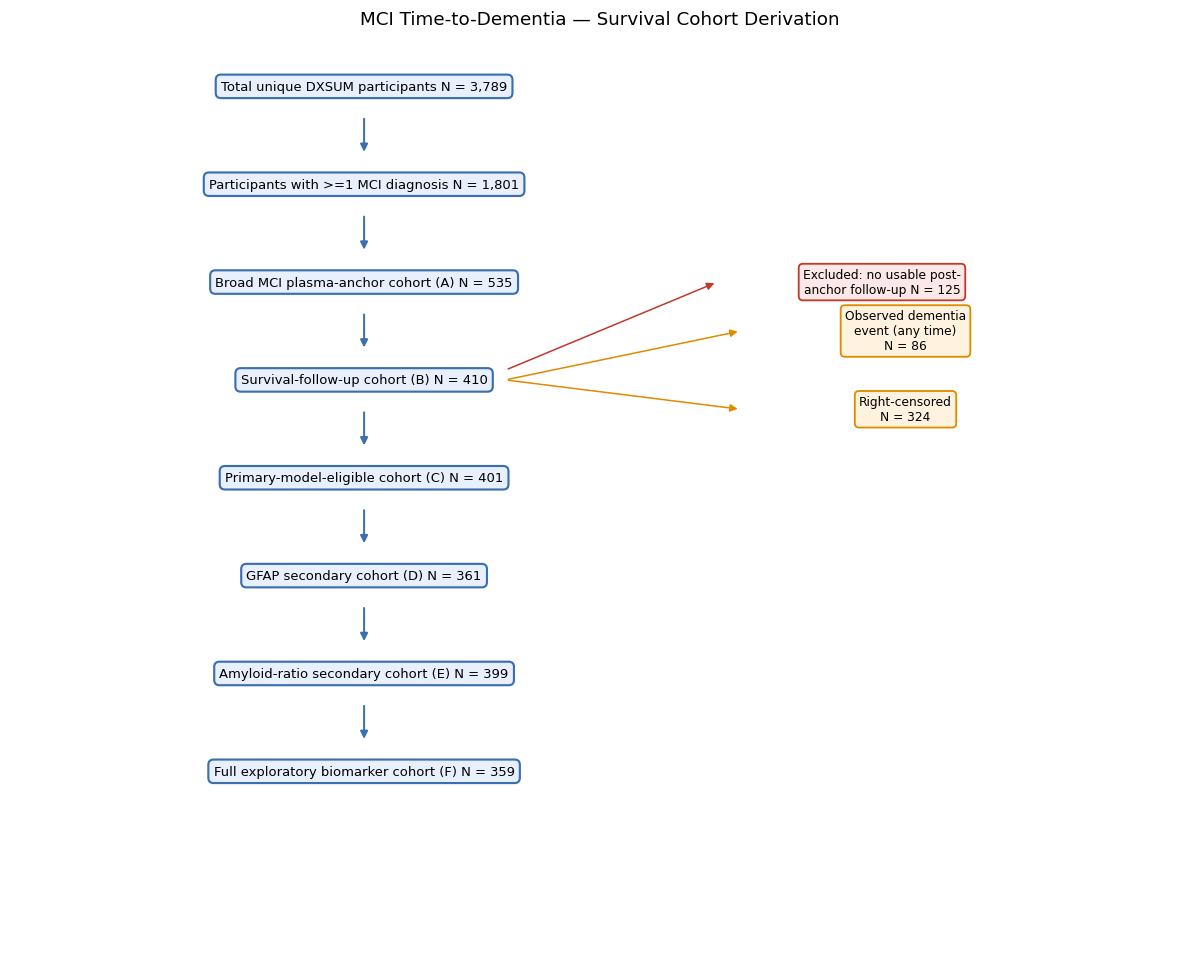

,step,n,notes
0,Total unique DXSUM participants,3789,
1,Participants with >=1 MCI diagnosis,1801,
2,Broad MCI plasma-anchor cohort (A),535,"earliest MCI plasma draw, >=1 usable assay"
3,Excluded: no usable post-anchor follow-up,125,no valid post-anchor dx / event
4,Survival-follow-up cohort (B),410,A minus no-follow-up
5,Observed dementia event (any time),86,
6,Right-censored without dementia,324,censor at last non-dementia visit
7,Primary-model-eligible cohort (C),401,+entry_age +APOE4 +p-tau217
8,GFAP secondary cohort (D),361,C + GFAP
9,Amyloid-ratio secondary cohort (E),399,C + Aβ42 + Aβ40 + ratio


In [12]:
n_total = dxsum["RID"].nunique()
n_mci_any = dxh.loc[dxh["dx_harmonized"] == "MCI", "RID"].nunique()
n_no_fu = int(master["no_usable_followup_flag"].sum())
elig = master[master["survival_followup_eligible_flag"]]
n_event_any = int((elig["event_indicator"] == 1).sum())
n_cens = int((elig["event_indicator"] == 0).sum())
n_gfap = int(master["has_gfap_secondary"].sum())
n_amy = int(master["has_amyloid_ratio_secondary"].sum())
n_full = int(master["has_full_exploratory"].sum())

flow = pd.DataFrame([
    ("Total unique DXSUM participants", n_total, ""),
    ("Participants with >=1 MCI diagnosis", n_mci_any, ""),
    ("Broad MCI plasma-anchor cohort (A)", n_broad, "earliest MCI plasma draw, >=1 usable assay"),
    ("Excluded: no usable post-anchor follow-up", n_no_fu, "no valid post-anchor dx / event"),
    ("Survival-follow-up cohort (B)", n_surv, "A minus no-follow-up"),
    ("Observed dementia event (any time)", n_event_any, ""),
    ("Right-censored without dementia", n_cens, "censor at last non-dementia visit"),
    ("Primary-model-eligible cohort (C)", n_primary, "+entry_age +APOE4 +p-tau217"),
    ("GFAP secondary cohort (D)", n_gfap, "C + GFAP"),
    ("Amyloid-ratio secondary cohort (E)", n_amy, "C + Aβ42 + Aβ40 + ratio"),
    ("Full exploratory biomarker cohort (F)", n_full, "C + GFAP + NfL + ratio"),
], columns=["step", "n", "notes"])
save_table(flow, "survival_cohort_flow_counts.csv")

fig, ax = plt.subplots(figsize=(11, 9)); ax.axis("off")
main = [r for _, r in flow.iterrows() if not r["step"].startswith("Excluded")
        and r["step"] not in ("Observed dementia event (any time)", "Right-censored without dementia")]
y, dy = 1.0, 1.0 / 9
box = dict(boxstyle="round,pad=0.4", facecolor="#e8f0fe", edgecolor="#3b6fb0", lw=1.4)
ys = []
for r in main:
    ax.text(0.30, y, textwrap.fill(f"{r['step']}\nN = {r['n']:,}", 46),
            ha="center", va="center", fontsize=8.6, bbox=box)
    ys.append(y); y -= dy
for i in range(len(ys) - 1):
    ax.annotate("", xy=(0.30, ys[i+1] + dy*0.30), xytext=(0.30, ys[i] - dy*0.30),
                arrowprops=dict(arrowstyle="-|>", color="#3b6fb0", lw=1.3))
# side annotations
sb = dict(boxstyle="round,pad=0.35", facecolor="#fff3e0", edgecolor="#e08a00", lw=1.2)
anchor_y = ys[2]
ax.text(0.74, anchor_y, textwrap.fill(f"Excluded: no usable\npost-anchor follow-up\nN = {n_no_fu:,}", 26),
        ha="center", va="center", fontsize=8, bbox=dict(boxstyle="round,pad=0.35", facecolor="#fde8e8",
        edgecolor="#c0392b", lw=1.2))
ax.annotate("", xy=(0.60, anchor_y), xytext=(0.42, ys[3]+dy*0.1),
            arrowprops=dict(arrowstyle="-|>", color="#c0392b", lw=1.0))
surv_y = ys[3]
for j, (lab, val, col) in enumerate([(f"Observed dementia\nevent (any time)\nN = {n_event_any:,}", n_event_any, "#e08a00"),
                                     (f"Right-censored\nN = {n_cens:,}", n_cens, "#e08a00")]):
    ax.text(0.76, surv_y + dy*0.5 - j*dy*0.8, lab, ha="center", va="center", fontsize=8, bbox=sb)
    ax.annotate("", xy=(0.62, surv_y + dy*0.5 - j*dy*0.8), xytext=(0.42, surv_y),
                arrowprops=dict(arrowstyle="-|>", color="#e08a00", lw=1.0))
ax.set_title("MCI Time-to-Dementia — Survival Cohort Derivation", fontsize=12, pad=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05); plt.tight_layout()
fig.savefig(OUT_DIR / "survival_cohort_flowchart.png", dpi=150, bbox_inches="tight")
print("saved -> survival_cohort_flowchart.png")
plt.show()
flow


## 11. Follow-up and event audit

In [13]:
elig = master[master["survival_followup_eligible_flag"]].copy()
t = elig["time_to_event_or_censor_days"]; ev = elig["event_indicator"]
N = len(elig)
def pct(x): return round(100 * x / N, 1) if N else np.nan
event_after_730 = int(((ev == 1) & (t > 730)).sum())
fu_ge24_noevent = int((((ev == 0) & (t >= 730)) | ((ev == 1) & (t > 730))).sum())
fu_lt24_cens = int(((ev == 0) & (t < 730)).sum())

evt_tbl = pd.DataFrame([
    ("Survival-follow-up cohort", N, 100.0),
    ("Observed dementia event (any time)", int((ev == 1).sum()), pct((ev == 1).sum())),
    ("Right-censored", int((ev == 0).sum()), pct((ev == 0).sum())),
    ("Dementia event by 12 months", int(((ev == 1) & (t <= 365)).sum()), pct(((ev == 1) & (t <= 365)).sum())),
    ("Dementia event by 24 months", int(((ev == 1) & (t <= 730)).sum()), pct(((ev == 1) & (t <= 730)).sum())),
    ("Dementia event by 36 months", int(((ev == 1) & (t <= 1095)).sum()), pct(((ev == 1) & (t <= 1095)).sum())),
    ("Follow-up >=24m without prior event", fu_ge24_noevent, pct(fu_ge24_noevent)),
    ("Follow-up <24m and censored", fu_lt24_cens, pct(fu_lt24_cens)),
    ("No usable post-anchor follow-up (excluded)", n_no_fu, np.nan),
], columns=["group", "n", "percent"])
save_table(evt_tbl, "survival_followup_event_summary.csv")

evt = elig[ev == 1]["time_to_event_or_censor_days"]
desc = pd.DataFrame([
    ("median follow-up (days)", round(t.median(), 1)),
    ("IQR follow-up (days)", f"{t.quantile(.25):.0f}-{t.quantile(.75):.0f}"),
    ("min / max follow-up (days)", f"{t.min():.0f} / {t.max():.0f}"),
    ("median time-to-dementia among events (days)", round(evt.median(), 1)),
    ("IQR time-to-dementia (days)", f"{evt.quantile(.25):.0f}-{evt.quantile(.75):.0f}"),
    ("events after 24 months", event_after_730),
    ("same-day diagnosis-conflict records", int(master["sameday_dementia_at_anchor"].sum())),
], columns=["metric", "value"])
save_table(desc, "survival_followup_descriptives.csv")
print(evt_tbl.to_string(index=False)); print(); print(desc.to_string(index=False))
evt_tbl


  saved -> outputs/01b_mci_survival_cohort_audit/survival_followup_event_summary.csv  (9x3)
  saved -> outputs/01b_mci_survival_cohort_audit/survival_followup_descriptives.csv  (7x2)
                                     group   n  percent
                 Survival-follow-up cohort 410    100.0
        Observed dementia event (any time)  86     21.0
                            Right-censored 324     79.0
               Dementia event by 12 months  15      3.7
               Dementia event by 24 months  34      8.3
               Dementia event by 36 months  56     13.7
       Follow-up >=24m without prior event 161     39.3
               Follow-up <24m and censored 215     52.4
No usable post-anchor follow-up (excluded) 125      NaN

                                     metric    value
                    median follow-up (days)    420.0
                       IQR follow-up (days) 229-1111
                 min / max follow-up (days) 1 / 3694
median time-to-dementia among events (days) 

,group,n,percent
0,Survival-follow-up cohort,410,100.0
1,Observed dementia event (any time),86,21.0
2,Right-censored,324,79.0
3,Dementia event by 12 months,15,3.7
4,Dementia event by 24 months,34,8.3
5,Dementia event by 36 months,56,13.7
6,Follow-up >=24m without prior event,161,39.3
7,Follow-up <24m and censored,215,52.4
8,No usable post-anchor follow-up (excluded),125,NaN


## 12. Kaplan–Meier feasibility visualization (descriptive, unadjusted)

Implemented from first principles (no `lifelines`): product-limit estimator with Greenwood
pointwise standard errors. **Descriptive only — no causal claims, no stratification.**

  saved -> outputs/01b_mci_survival_cohort_audit/km_survival_estimate.csv  (79x6)
  saved -> outputs/01b_mci_survival_cohort_audit/km_number_at_risk.csv  (7x2)


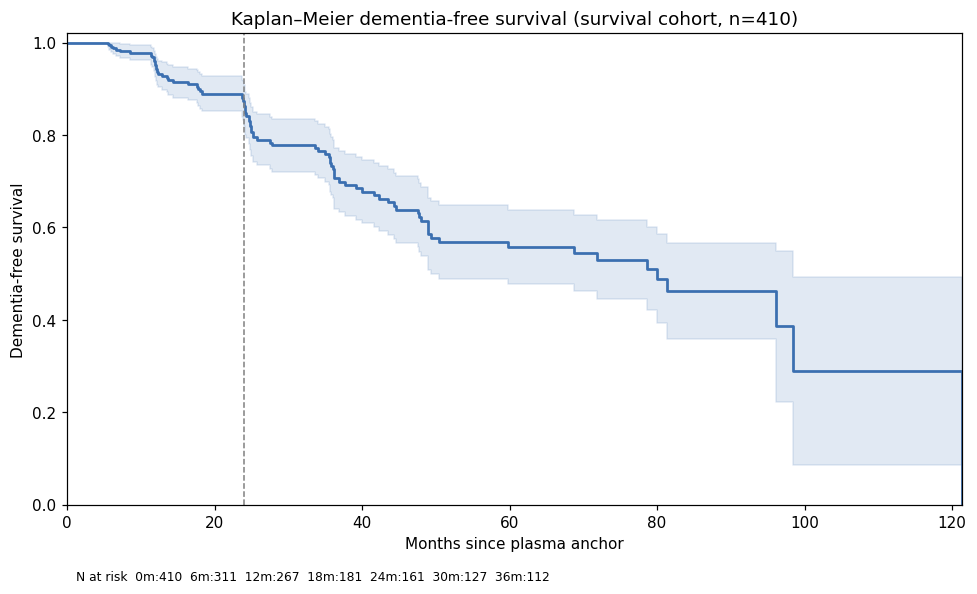

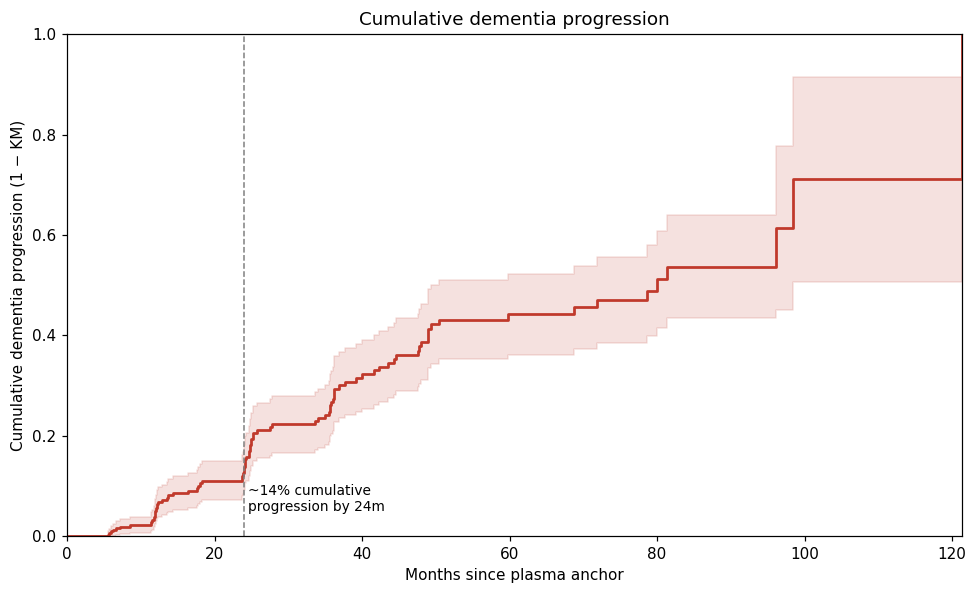

Number-at-risk: {0: 410, 6: 311, 12: 267, 18: 181, 24: 161, 30: 127, 36: 112}
KM-estimated cumulative progression by 24m: 13.7%


In [14]:
def km_estimate(time, event):
    df = pd.DataFrame({"t": np.asarray(time, float), "e": np.asarray(event, float)})
    df = df[df["t"] > 0].sort_values("t")
    n = len(df)
    etimes = np.sort(df.loc[df["e"] == 1, "t"].unique())
    S, varsum, rows = 1.0, 0.0, [(0.0, n, 0, 1.0, 0.0)]
    for tt in etimes:
        n_risk = int((df["t"] >= tt).sum())
        d = int(((df["t"] == tt) & (df["e"] == 1)).sum())
        if n_risk == 0:
            continue
        S *= (1 - d / n_risk)
        if n_risk > d:
            varsum += d / (n_risk * (n_risk - d))
        rows.append((float(tt), n_risk, d, S, S * np.sqrt(varsum)))
    return pd.DataFrame(rows, columns=["t_days", "n_risk", "n_event", "survival", "se"])


def n_at_risk(time, months):
    days = np.asarray(time, float)
    return [int((days >= m * DAYS_PER_MONTH).sum()) for m in months]


km = km_estimate(elig["time_to_event_or_censor_days"], elig["event_indicator"])
km["t_months"] = km["t_days"] / DAYS_PER_MONTH
risk_months = [0, 6, 12, 18, 24, 30, 36]
risk_counts = n_at_risk(elig["time_to_event_or_censor_days"], risk_months)
risk_tbl = pd.DataFrame({"month": risk_months, "n_at_risk": risk_counts})
save_table(km, "km_survival_estimate.csv")
save_table(risk_tbl, "km_number_at_risk.csv")

# ---- KM dementia-free survival ----
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.step(km["t_months"], km["survival"], where="post", color="#3b6fb0", lw=1.8)
lo = np.clip(km["survival"] - 1.96*km["se"], 0, 1); hi = np.clip(km["survival"] + 1.96*km["se"], 0, 1)
ax.fill_between(km["t_months"], lo, hi, step="post", alpha=0.15, color="#3b6fb0")
ax.axvline(24, color="grey", ls="--", lw=1); ax.set_ylim(0, 1.02); ax.set_xlim(0, max(48, km["t_months"].max()))
ax.set_xlabel("Months since plasma anchor"); ax.set_ylabel("Dementia-free survival")
ax.set_title(f"Kaplan–Meier dementia-free survival (survival cohort, n={N})")
tbl_txt = "  ".join(f"{m}m:{c}" for m, c in zip(risk_months, risk_counts))
ax.text(0.01, -0.16, "N at risk  " + tbl_txt, transform=ax.transAxes, fontsize=8)
plt.tight_layout(); fig.savefig(OUT_DIR / "km_dementia_free_survival.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- cumulative progression = 1 - S ----
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.step(km["t_months"], 1 - km["survival"], where="post", color="#c0392b", lw=1.8)
ax.fill_between(km["t_months"], 1-hi, 1-lo, step="post", alpha=0.15, color="#c0392b")
ax.axvline(24, color="grey", ls="--", lw=1)
s24 = km.loc[km["t_days"] <= 730, "survival"]
cum24 = (1 - s24.iloc[-1]) if len(s24) else np.nan
ax.text(24.5, 0.05, f"~{cum24*100:.0f}% cumulative\nprogression by 24m", fontsize=9)
ax.set_ylim(0, min(1.0, (1-km["survival"]).max()*1.3 + 0.05)); ax.set_xlim(0, max(48, km["t_months"].max()))
ax.set_xlabel("Months since plasma anchor"); ax.set_ylabel("Cumulative dementia progression (1 − KM)")
ax.set_title("Cumulative dementia progression")
plt.tight_layout(); fig.savefig(OUT_DIR / "km_cumulative_progression.png", dpi=150, bbox_inches="tight"); plt.show()
print("Number-at-risk:", dict(zip(risk_months, risk_counts)))
print(f"KM-estimated cumulative progression by 24m: {cum24*100:.1f}%")


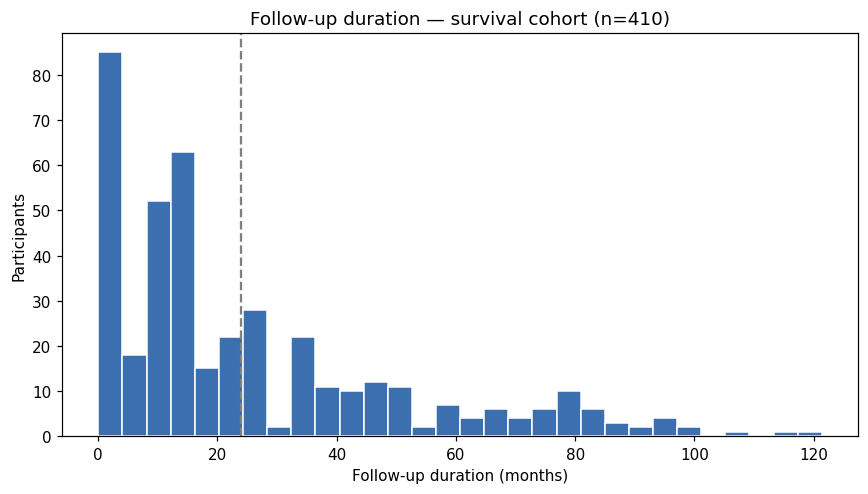

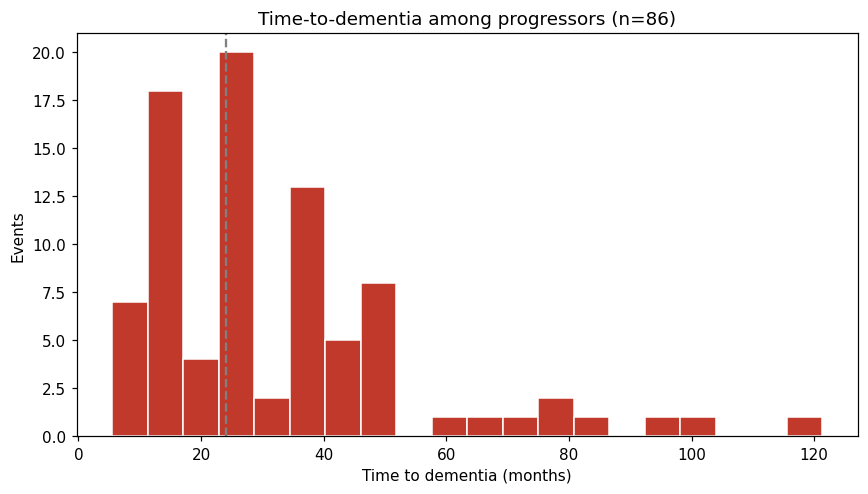

In [15]:
# ---- follow-up duration & event-time distributions ----
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(elig["time_to_event_or_censor_days"]/DAYS_PER_MONTH, bins=30, color="#3b6fb0", edgecolor="white")
ax.axvline(24, color="grey", ls="--"); ax.set_xlabel("Follow-up duration (months)"); ax.set_ylabel("Participants")
ax.set_title(f"Follow-up duration — survival cohort (n={N})")
plt.tight_layout(); fig.savefig(OUT_DIR / "followup_duration_distribution.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(evt/DAYS_PER_MONTH, bins=20, color="#c0392b", edgecolor="white")
ax.axvline(24, color="grey", ls="--"); ax.set_xlabel("Time to dementia (months)"); ax.set_ylabel("Events")
ax.set_title(f"Time-to-dementia among progressors (n={int((ev==1).sum())})")
plt.tight_layout(); fig.savefig(OUT_DIR / "event_time_distribution.png", dpi=150, bbox_inches="tight"); plt.show()


## 13. Predictor availability and missingness (no imputation)

  saved -> outputs/01b_mci_survival_cohort_audit/survival_predictor_missingness.csv  (13x7)
  saved -> outputs/01b_mci_survival_cohort_audit/survival_predictor_missingness_by_event.csv  (13x3)


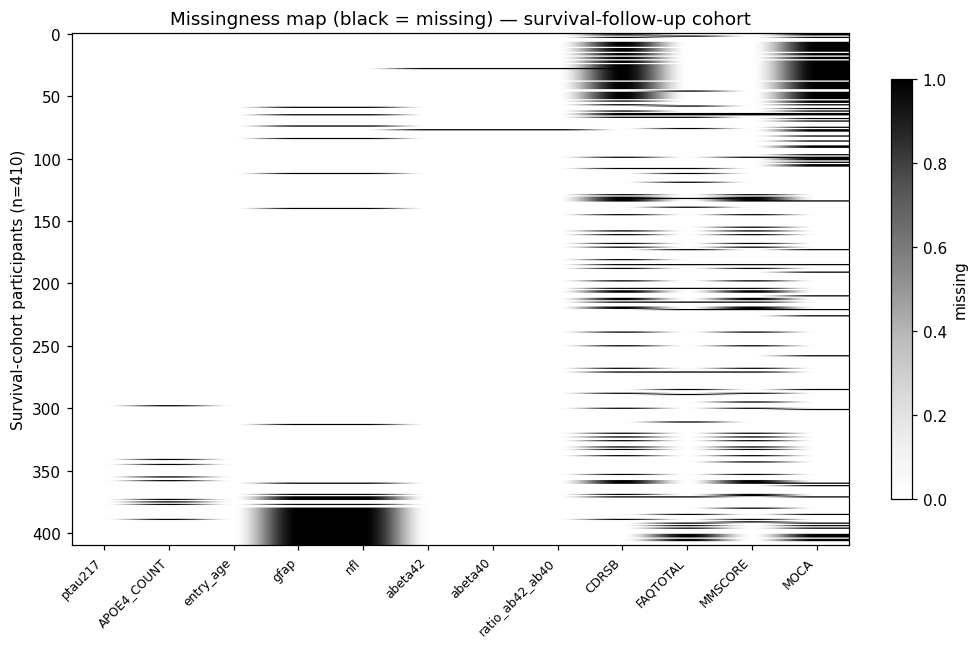

,variable,raw_column,role,cohort,n_available,n_missing,pct_missing
0,ptau217,pT217_F,primary,Survival-follow-up (B),410,0,0.0
1,APOE4_COUNT,GENOTYPE,primary,Survival-follow-up (B),401,9,2.2
2,entry_age,entry_age,primary,Survival-follow-up (B),410,0,0.0
3,age_at_anchor_approx,derived,primary(approx),Survival-follow-up (B),410,0,0.0
4,gfap,GFAP_Q,secondary,Survival-follow-up (B),367,43,10.5
5,nfl,NfL_Q,secondary,Survival-follow-up (B),367,43,10.5
6,abeta42,AB42_F,secondary,Survival-follow-up (B),408,2,0.5
7,abeta40,AB40_F,secondary,Survival-follow-up (B),408,2,0.5
8,ratio_ab42_ab40,AB42_F/AB40_F,secondary,Survival-follow-up (B),408,2,0.5
9,CDRSB,CDRSB,benchmark,Survival-follow-up (B),321,89,21.7


In [16]:
PRED_VARS = [
    ("ptau217", "pT217_F", "primary"), ("APOE4_COUNT", "GENOTYPE", "primary"),
    ("entry_age", "entry_age", "primary"), ("age_at_anchor_approx", "derived", "primary(approx)"),
    ("gfap", "GFAP_Q", "secondary"), ("nfl", "NfL_Q", "secondary"),
    ("abeta42", "AB42_F", "secondary"), ("abeta40", "AB40_F", "secondary"),
    ("ratio_ab42_ab40", "AB42_F/AB40_F", "secondary"),
    ("CDRSB", "CDRSB", "benchmark"), ("FAQTOTAL", "FAQTOTAL", "benchmark"),
    ("MMSCORE", "MMSCORE", "benchmark"), ("MOCA", "MOCA", "benchmark"),
]

def missingness(df, label):
    n = len(df); rows = []
    for var, raw, role in PRED_VARS:
        av = int(df[var].notna().sum()) if var in df else 0
        rows.append(dict(variable=var, raw_column=raw, role=role, cohort=label,
                         n_available=av, n_missing=n-av,
                         pct_missing=round(100*(n-av)/n, 1) if n else np.nan))
    return pd.DataFrame(rows)

miss = missingness(elig, "Survival-follow-up (B)")
save_table(miss, "survival_predictor_missingness.csv")

ev_df = elig[elig["event_indicator"] == 1]; ce_df = elig[elig["event_indicator"] == 0]
by_ev = (missingness(ev_df, "event")[["variable", "pct_missing"]].rename(columns={"pct_missing": "event_pct_missing"})
         .merge(missingness(ce_df, "censored")[["variable", "pct_missing"]]
                .rename(columns={"pct_missing": "censored_pct_missing"}), on="variable"))
save_table(by_ev, "survival_predictor_missingness_by_event.csv")

hm_vars = ["ptau217", "APOE4_COUNT", "entry_age", "gfap", "nfl", "abeta42", "abeta40",
           "ratio_ab42_ab40", "CDRSB", "FAQTOTAL", "MMSCORE", "MOCA"]
M = elig[hm_vars].isna().astype(int).values
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(M, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_xticks(range(len(hm_vars))); ax.set_xticklabels(hm_vars, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"Survival-cohort participants (n={N})")
ax.set_title("Missingness map (black = missing) — survival-follow-up cohort")
plt.colorbar(im, ax=ax, fraction=0.025, label="missing"); plt.tight_layout()
fig.savefig(OUT_DIR / "survival_missingness_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()
miss


## 14. Descriptive baseline predictors: event vs censored

For the **primary-model-eligible** cohort. Descriptive only — censoring *duration* differs
between groups, so this is **not** an adjusted survival comparison. "Censored" does **not**
mean permanently stable (many are simply followed for less time).

  saved -> outputs/01b_mci_survival_cohort_audit/survival_baseline_characteristics_by_event.csv  (13x8)


/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53637/2229806071.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["event", "censored"], showfliers=False)
/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53637/2229806071.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["event", "censored"], showfliers=False)
/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw0000gn/T/ipykernel_53637/2229806071.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["event", "censored"], showfliers=False)
/var/folders/w0/vpjflhqx1z3dt_bmk6rwvkdw000

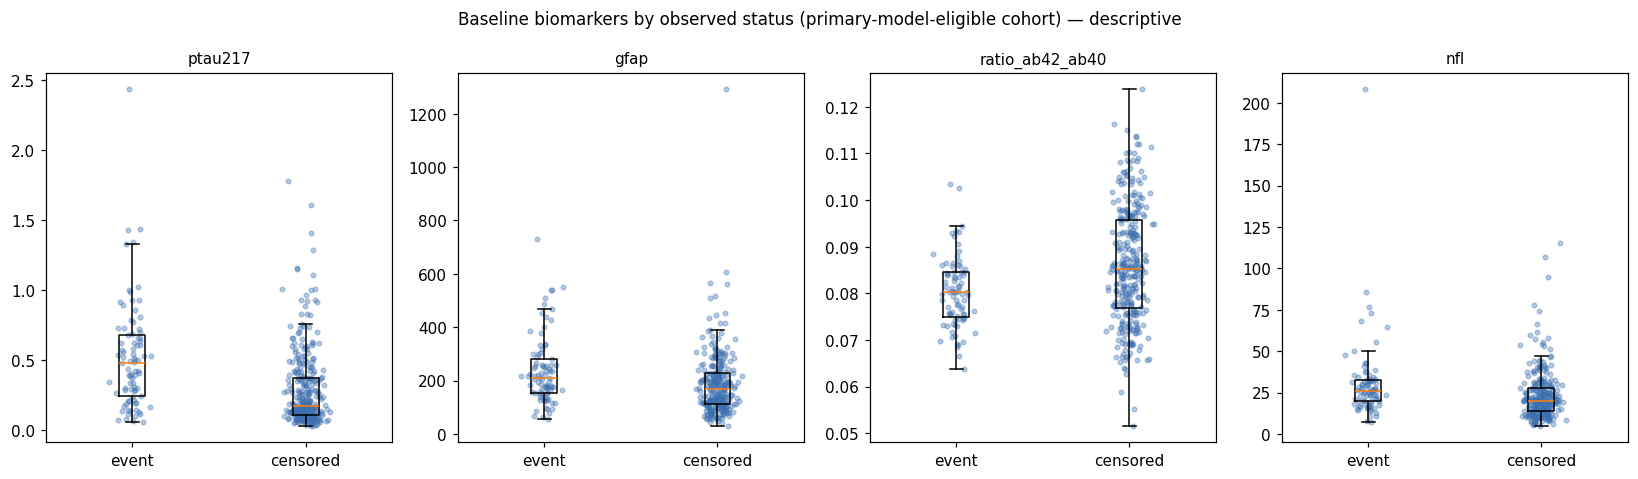

,variable,event_n,event_mean_sd,event_median_iqr,censored_n,censored_mean_sd,censored_median_iqr,SMD
0,entry_age,85,75.2 ± 6.56,"75.5 [70.9, 79.9]",316,71.8 ± 7.3,"72 [66.9, 77.2]",0.484
1,age_at_anchor_approx,85,75.7 ± 6.88,"75.7 [70.9, 80.7]",316,74.3 ± 8.48,"74.5 [68.2, 80]",0.183
2,APOE4_COUNT,85,0.671 ± 0.643,"1 [0, 1]",316,0.541 ± 0.682,"0 [0, 1]",0.195
3,ptau217,85,0.517 ± 0.384,"0.474 [0.241, 0.68]",316,0.286 ± 0.272,"0.172 [0.104, 0.372]",0.693
4,gfap,85,238 ± 128,"211 [154, 281]",276,188 ± 120,"168 [112, 230]",0.407
5,nfl,85,30.7 ± 24.4,"25.8 [19.7, 32.3]",276,23.2 ± 15.1,"19.6 [13.9, 27.9]",0.371
6,abeta42,83,23.2 ± 6.81,"23.2 [20.2, 27.1]",316,26.9 ± 6.4,"26.8 [22.5, 30.3]",-0.568
7,abeta40,83,291 ± 83.3,"291 [252, 338]",316,315 ± 68.1,"311 [274, 349]",-0.321
8,ratio_ab42_ab40,83,0.0802 ± 0.00755,"0.0802 [0.0749, 0.0845]",316,0.086 ± 0.0125,"0.0852 [0.0769, 0.0957]",-0.564
9,CDRSB,50,2.29 ± 1.66,"2 [1.5, 2.5]",264,1.38 ± 1.03,"1 [0.5, 2]",0.660


In [17]:
def smd(a, b):
    a, b = a.dropna(), b.dropna()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return np.nan if sp == 0 else (a.mean() - b.mean()) / sp

prim = master[master["has_primary"]].copy()
pe = prim[prim["event_indicator"] == 1]; pc = prim[prim["event_indicator"] == 0]
cont = ["entry_age", "age_at_anchor_approx", "APOE4_COUNT", "ptau217", "gfap",
        "nfl", "abeta42", "abeta40", "ratio_ab42_ab40", "CDRSB", "FAQTOTAL", "MMSCORE", "MOCA"]
rows = []
for v in cont:
    e, c = pe[v], pc[v]
    rows.append(dict(variable=v,
        event_n=int(e.notna().sum()),
        event_mean_sd=f"{e.mean():.3g} ± {e.std():.3g}" if e.notna().sum() else "-",
        event_median_iqr=f"{e.median():.3g} [{e.quantile(.25):.3g}, {e.quantile(.75):.3g}]" if e.notna().sum() else "-",
        censored_n=int(c.notna().sum()),
        censored_mean_sd=f"{c.mean():.3g} ± {c.std():.3g}" if c.notna().sum() else "-",
        censored_median_iqr=f"{c.median():.3g} [{c.quantile(.25):.3g}, {c.quantile(.75):.3g}]" if c.notna().sum() else "-",
        SMD=round(smd(e, c), 3)))
baseline_by_event = pd.DataFrame(rows)
save_table(baseline_by_event, "survival_baseline_characteristics_by_event.csv")

plot_vars = ["ptau217", "gfap", "ratio_ab42_ab40", "nfl"]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.4))
for ax, v in zip(axes, plot_vars):
    data = [pe[v].dropna(), pc[v].dropna()]
    if all(len(d) for d in data):
        ax.boxplot(data, labels=["event", "censored"], showfliers=False)
        for i, d in enumerate(data, 1):
            xs = np.random.default_rng(i).normal(i, 0.05, len(d))
            ax.scatter(xs, d, s=9, alpha=0.35, color="#3b6fb0")
    ax.set_title(v, fontsize=10)
fig.suptitle("Baseline biomarkers by observed status (primary-model-eligible cohort) — descriptive", fontsize=11)
plt.tight_layout(); fig.savefig(OUT_DIR / "survival_biomarker_distributions_by_event.png", dpi=150, bbox_inches="tight"); plt.show()
baseline_by_event


## 15. Data dictionary

In [18]:
dd = pd.DataFrame([
    dict(analysis_variable="anchor_date", source="UPENN_PLASMA", raw_column="EXAMDATE",
         timepoint_rule="earliest usable-assay MCI plasma draw", definition="survival time origin",
         unit="date", role="plasma anchor QC field", notes="±90d dx alignment"),
    dict(analysis_variable="anchor_dx_date", source="DXSUM", raw_column="EXAMDATE",
         timepoint_rule="nearest MCI dx within ±90d", definition="aligned MCI diagnosis date",
         unit="date", role="plasma anchor QC field", notes="see align_offset_days"),
    dict(analysis_variable="align_offset_days", source="derived", raw_column="anchor-dx dates",
         timepoint_rule="anchor", definition="blood-to-diagnosis time gap", unit="days",
         role="plasma anchor QC field", notes="same_day_alignment flag records 0d"),
    dict(analysis_variable="ptau217", source="UPENN_PLASMA", raw_column="pT217_F",
         timepoint_rule="anchor", definition="Fujirebio plasma p-tau217", unit="pg/mL",
         role="primary predictor", notes="log-transform likely; never missing in file"),
    dict(analysis_variable="APOE4_COUNT", source="APOERES", raw_column="GENOTYPE",
         timepoint_rule="time-invariant", definition="count of '4' alleles", unit="0-2",
         role="genetic covariate", notes=""),
    dict(analysis_variable="entry_age", source="My_Table", raw_column="entry_age",
         timepoint_rule="study entry (undated)", definition="age at study entry", unit="years",
         role="demographic covariate", notes="LABELLED primary age; no datestamp in source"),
    dict(analysis_variable="age_at_anchor_approx", source="derived", raw_column="entry_age + gap",
         timepoint_rule="anchor", definition="entry_age + (anchor - earliest dated dx)/365.25",
         unit="years", role="demographic covariate", notes="APPROX; age_is_entry_age_fallback flag set"),
    dict(analysis_variable="gfap", source="UPENN_PLASMA", raw_column="GFAP_Q",
         timepoint_rule="anchor", definition="Quanterix plasma GFAP", unit="pg/mL",
         role="secondary predictor", notes=""),
    dict(analysis_variable="nfl", source="UPENN_PLASMA", raw_column="NfL_Q",
         timepoint_rule="anchor", definition="Quanterix plasma NfL", unit="pg/mL",
         role="secondary predictor", notes=""),
    dict(analysis_variable="abeta42", source="UPENN_PLASMA", raw_column="AB42_F",
         timepoint_rule="anchor", definition="Fujirebio Aβ42", unit="pg/mL",
         role="secondary predictor", notes=""),
    dict(analysis_variable="abeta40", source="UPENN_PLASMA", raw_column="AB40_F",
         timepoint_rule="anchor", definition="Fujirebio Aβ40", unit="pg/mL",
         role="secondary predictor", notes=""),
    dict(analysis_variable="ratio_ab42_ab40", source="derived", raw_column="AB42_F/AB40_F",
         timepoint_rule="anchor", definition="recomputed Aβ42/Aβ40 ratio", unit="ratio",
         role="secondary predictor", notes="vendor AB42_AB40_F kept separately"),
    dict(analysis_variable="CDRSB/FAQTOTAL/MMSCORE/MOCA", source="CDR/FAQ/MMSE/MOCA",
         raw_column="CDRSB/FAQTOTAL/MMSCORE/MOCA", timepoint_rule="anchor ±90d",
         definition="cognitive/functional scores", unit="scale", role="clinical benchmark",
         notes="future benchmark only"),
    dict(analysis_variable="event_indicator", source="DXSUM(follow-up)", raw_column="DIAGNOSIS",
         timepoint_rule="post-anchor", definition="1=dementia observed, 0=censored", unit="0/1",
         role="survival event variable", notes="first post-anchor Dementia"),
    dict(analysis_variable="time_to_event_or_censor_days", source="derived", raw_column="dates",
         timepoint_rule="post-anchor", definition="anchor->event or anchor->last non-dementia",
         unit="days", role="survival event variable", notes=""),
    dict(analysis_variable="censor_date", source="DXSUM(follow-up)", raw_column="EXAMDATE",
         timepoint_rule="last non-dementia post-anchor", definition="censoring date", unit="date",
         role="censoring variable", notes="no death table -> admin censor at last clinical dx"),
    dict(analysis_variable="survival_followup_eligible_flag", source="derived", raw_column="-",
         timepoint_rule="-", definition="has >=1 usable post-anchor dx or event", unit="bool",
         role="exclusion/QC flag", notes="no_usable_followup_flag is its complement"),
    dict(analysis_variable="age_derivation_suspect / sameday_dementia_at_anchor / reverted_cn",
         source="derived", raw_column="-", timepoint_rule="-",
         definition="QC edge-case flags", unit="bool/int", role="exclusion/QC flag", notes=""),
])
save_table(dd, "data_dictionary_mci_survival_study.csv")
dd


  saved -> outputs/01b_mci_survival_cohort_audit/data_dictionary_mci_survival_study.csv  (18x8)


,analysis_variable,source,raw_column,timepoint_rule,definition,unit,role,notes
0,anchor_date,UPENN_PLASMA,EXAMDATE,earliest usable-assay MCI plasma draw,survival time origin,date,plasma anchor QC field,±90d dx alignment
1,anchor_dx_date,DXSUM,EXAMDATE,nearest MCI dx within ±90d,aligned MCI diagnosis date,date,plasma anchor QC field,see align_offset_days
2,align_offset_days,derived,anchor-dx dates,anchor,blood-to-diagnosis time gap,days,plasma anchor QC field,same_day_alignment flag records 0d
3,ptau217,UPENN_PLASMA,pT217_F,anchor,Fujirebio plasma p-tau217,pg/mL,primary predictor,log-transform likely; never missing in file
4,APOE4_COUNT,APOERES,GENOTYPE,time-invariant,count of '4' alleles,0-2,genetic covariate,
5,entry_age,My_Table,entry_age,study entry (undated),age at study entry,years,demographic covariate,LABELLED primary age; no datestamp in source
6,age_at_anchor_approx,derived,entry_age + gap,anchor,entry_age + (anchor - earliest dated dx)/365.25,years,demographic covariate,APPROX; age_is_entry_age_fallback flag set
7,gfap,UPENN_PLASMA,GFAP_Q,anchor,Quanterix plasma GFAP,pg/mL,secondary predictor,
8,nfl,UPENN_PLASMA,NfL_Q,anchor,Quanterix plasma NfL,pg/mL,secondary predictor,
9,abeta42,UPENN_PLASMA,AB42_F,anchor,Fujirebio Aβ42,pg/mL,secondary predictor,


## 16. Feasibility Conclusion for Time-to-Dementia Survival Modeling

In [19]:
age_valid = False  # entry_age has no datestamp -> age_at_anchor not VALIDLY derivable
n_primary_events = int((prim["event_indicator"] == 1).sum())
n_primary_e24 = int(((prim["event_indicator"] == 1) & (prim["time_to_event_or_censor_days"] <= 730)).sum())
recovered = n_surv - 139   # vs prior strict 24-month ascertained cohort

L = []
L.append(f" 1. Broad MCI plasma-anchor cohort (A): {n_broad}")
L.append(f" 2. Contribute post-anchor survival follow-up (B): {n_surv} "
         f"({100*n_surv/n_broad:.0f}% of A)")
L.append(f" 3. Observed dementia events (any time): {n_event_any}")
L.append(f" 4. Events by 24 months: {int(((ev==1)&(t<=730)).sum())}")
L.append(f" 5. Primary-model-eligible cohort (C): {n_primary}")
L.append(f" 6. Events within primary-model-eligible cohort: {n_primary_events} "
         f"(by 24m: {n_primary_e24})")
L.append(f" 7. age_at_anchor validly derivable? NO -> entry_age retained (no datestamp in source); "
         f"age_at_anchor_approx provided & flagged.")
L.append(f" 8. Broader anchor materially increases cohort size? NO -> broad ({n_broad}) == "
         f"prior p-tau217 anchor ({n_prior}); p-tau217 never missing.")
L.append(f" 9. Survival recovers data lost by strict 24m binary? YES -> {n_surv} contribute vs "
         f"139 strict-ascertained (+{recovered}); events {n_event_any} vs 34 by-24m.")
epv = n_primary_events / 3  # 3 primary predictors
L.append(f"10. Event count: ~{n_primary_events} primary-cohort events => ~{epv:.0f} events per "
         f"predictor at 3 predictors ({'adequate for a tiny penalized pilot' if epv>=10 else 'supports only a very small/reduced pilot'}).")
L.append(f"11. Largest bias/uncertainty: informative/administrative censoring (no death or "
         f"loss-to-follow-up table; censor at last clinical visit), variable follow-up length, "
         f"single-cohort ADNI data, and approximate age.")
print("\n".join(L))

if n_primary_events >= 40 and epv >= 10:
    rec = "A. Proceed to a tiny reduced-predictor penalized survival pilot"
elif n_primary_events >= 20:
    rec = "A. Proceed to a tiny reduced-predictor penalized survival pilot"
elif n_primary_events >= 10:
    rec = "B. Proceed only with a univariable / two-predictor exploratory survival analysis"
else:
    rec = "D. Do not proceed to survival modeling without more data"
print(f"\n12. Next notebook: 02_mci_time_to_dementia_survival_pilot.ipynb")
print(f"RECOMMENDATION -> {rec}")


 1. Broad MCI plasma-anchor cohort (A): 535
 2. Contribute post-anchor survival follow-up (B): 410 (77% of A)
 3. Observed dementia events (any time): 86
 4. Events by 24 months: 34
 5. Primary-model-eligible cohort (C): 401
 6. Events within primary-model-eligible cohort: 85 (by 24m: 33)
 7. age_at_anchor validly derivable? NO -> entry_age retained (no datestamp in source); age_at_anchor_approx provided & flagged.
 8. Broader anchor materially increases cohort size? NO -> broad (535) == prior p-tau217 anchor (535); p-tau217 never missing.
 9. Survival recovers data lost by strict 24m binary? YES -> 410 contribute vs 139 strict-ascertained (+271); events 86 vs 34 by-24m.
10. Event count: ~85 primary-cohort events => ~28 events per predictor at 3 predictors (adequate for a tiny penalized pilot).
11. Largest bias/uncertainty: informative/administrative censoring (no death or loss-to-follow-up table; censor at last clinical visit), variable follow-up length, single-cohort ADNI data, and a

### Interpretation

- The survival design's value is **not** a bigger anchor cohort (the broad anchor equals
  the prior p-tau217 anchor). It is that **right-censoring lets ~3× more participants
  contribute**, and roughly **2.5× more dementia events** become usable than the strict
  24-month binary allowed.
- Nothing here is diagnostic, validated, or clinically ready. This is a feasibility audit.
- The binding constraint on a pilot is the **number of events among primary-model-eligible
  participants**, printed above; predictors must stay minimal.
- **Censoring is administrative** (last clinical visit) — no death/LTFU dates exist — so
  the censoring mechanism may be informative; interpret future survival estimates cautiously.

## 17. Handoff to `02_mci_time_to_dementia_survival_pilot.ipynb` (plan only — do not implement)

*Proposed only if the feasibility recommendation above is A or B.*

**Primary model (constrained, fixed a priori):**
`age_at_anchor (or entry_age if necessary) + APOE4 count + p-tau217`.

**Restricted secondary additions, one at a time (never both, never automated):**
`+ GFAP`  *or*  `+ Aβ42/Aβ40 ratio`.

**Explicit constraints (mandatory):**
- **No automated feature selection** as the primary analysis.
- **No random survival forest** as the headline model (a penalized Cox / parametric model is the primary).
- All **scaling, imputation, and tuning must happen inside resampling folds only**.
- **Participant-level resampling only** (one row per participant; no visit leakage).
- **Calibration at 24 months is mandatory** (e.g. calibration curve / observed-vs-predicted at 730 d).
- Results are **exploratory and internally validated only** — external validation is required before any claim.

**Data gaps to close first:** obtain a reliable **age-at-visit** source (ADNI `PTDEMOG`) and,
if possible, **death / loss-to-follow-up** dates to reduce informative-censoring bias.

---
*All artifacts written to `outputs/01b_mci_survival_cohort_audit/`.*

In [20]:
print("Artifacts in", OUT_DIR.relative_to(PROJECT_ROOT), ":")
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:52s} {p.stat().st_size/1024:7.1f} KB")


Artifacts in outputs/01b_mci_survival_cohort_audit :
  anchor_definition_comparison.csv                         0.3 KB
  data_dictionary_mci_survival_study.csv                   2.3 KB
  data_discovery_survival_summary.csv                      1.2 KB
  diagnosis_harmonization_survival.csv                     0.4 KB
  event_time_distribution.png                             32.4 KB
  followup_duration_distribution.png                      30.6 KB
  km_cumulative_progression.png                           50.4 KB
  km_dementia_free_survival.png                           52.2 KB
  km_number_at_risk.csv                                    0.1 KB
  km_survival_estimate.csv                                 5.3 KB
  mci_survival_anchor_cohort_raw.csv                     193.9 KB
  survival_baseline_characteristics_by_event.csv           1.2 KB
  survival_biomarker_distributions_by_event.png          141.0 KB
  survival_cohort_flow_counts.csv                          0.6 KB
  survival_cohort_flowc